<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/%EB%AF%B8%EC%85%985_%EB%B6%84%EC%84%9D%EC%9E%90%EB%A3%8C_3%ED%8C%80_%EA%B9%80%EC%86%8C%EC%97%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                                3팀 김소연 스프린트 미션 5

최근 혈당관리는 건강관리의 가장 중요한 관심사

1. 파일 불러오기

In [ ]:
import pandas as pd

df = pd.read_csv('국민건강보험공단_건강검진정보_2023.CSV', encoding='euc-kr')

column_names = df.columns.tolist()
print(column_names)

['기준년도', '가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)', '신장(5cm단위)', '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압', '이완기혈압', '식전혈당(공복혈당)', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태', '음주여부', '구강검진수검여부', '치아우식증유무', '결손치 유무', '치아마모증유무', '제3대구치(사랑니) 이상', '치석']


2. 데이터 전처리 - 필요한 열 가져오기

In [ ]:
selected_columns = ['성별코드','연령대코드(5세단위)','신장(5cm단위)','체중(5kg단위)', '허리둘레','식전혈당(공복혈당)','수축기혈압', '이완기혈압',
'트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤', '총콜레스테롤','음주여부', '흡연상태','혈청지피티(ALT)','혈청지오티(AST)','감마지티피','혈청크레아티닌']

df_selected = df[selected_columns]
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   성별코드         1000000 non-null  int64  
 1   연령대코드(5세단위)  1000000 non-null  int64  
 2   신장(5cm단위)    1000000 non-null  int64  
 3   체중(5kg단위)    1000000 non-null  int64  
 4   허리둘레         999589 non-null   float64
 5   식전혈당(공복혈당)   994186 non-null   float64
 6   수축기혈압        994253 non-null   float64
 7   이완기혈압        994253 non-null   float64
 8   트리글리세라이드     338606 non-null   float64
 9   HDL콜레스테롤     338606 non-null   float64
 10  LDL콜레스테롤     332753 non-null   float64
 11  총콜레스테롤       338606 non-null   float64
 12  음주여부         999944 non-null   float64
 13  흡연상태         999911 non-null   float64
 14  혈청지피티(ALT)   994184 non-null   float64
 15  혈청지오티(AST)   994184 non-null   float64
 16  감마지티피        994187 non-null   float64
 17  혈청크레아티닌      994186 non-null   float64
dtypes: 

3. 더미로 변경 (주제변경으로 사용안함)

In [ ]:
#df_selected['과거흡연'] = (df_selected['흡연상태'] == 2).astype(int)
#df_selected['현재흡연'] = (df_selected['흡연상태'] == 3).astype(int)
#df_selected.describe()

4. 변수 추가(BMI, 대사증후군 지수, 심혈관 위험 지수)

In [ ]:
df_selected['BMI'] = df_selected['체중(5kg단위)'] / (df_selected['신장(5cm단위)'] / 100) ** 2


# 대사증후군 지수 계산
df_selected['대사증후군 지수'] = (
    0.3 * df_selected['허리둘레'] +
    0.2 * df_selected['수축기혈압'] +
    0.2 * df_selected['이완기혈압'] -
    0.1 * df_selected['HDL콜레스테롤'] +
    0.1 * df_selected['트리글리세라이드'] +
    0.1 * df_selected['식전혈당(공복혈당)']
)

# 심혈관 위험 지수 계산
df_selected['심혈관 위험 지수'] = (
    df_selected['총콜레스테롤'] +
    df_selected['LDL콜레스테롤'] -
    df_selected['HDL콜레스테롤'] +
    df_selected['트리글리세라이드'] )

# 간 기능 지수 계산
df_selected['간 기능 지수'] = (
    (df_selected['혈청지피티(ALT)'] + df_selected['혈청지오티(AST)']) / 2 +
    (df_selected['감마지티피'] / 3) +
    (df_selected['혈청크레아티닌'] / 4))

#LDL/HDL 지수 계산
df_selected['LDL/HDL'] = (
    df_selected['LDL콜레스테롤']  /
    df_selected['HDL콜레스테롤']
)

df_selected['연령대코드(5세단위)'] = df_selected['연령대코드(5세단위)'] * 5

C:\Users\김소연\AppData\Local\Temp\ipykernel_12000\472030227.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['BMI'] = df_selected['체중(5kg단위)'] / (df_selected['신장(5cm단위)'] / 100) ** 2
C:\Users\김소연\AppData\Local\Temp\ipykernel_12000\472030227.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['대사증후군 지수'] = (
C:\Users\김소연\AppData\Local\Temp\ipykernel_12000\472030227.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

5. 모든 이상치와 결측값 제거

In [ ]:

df_cleaned = df_selected.dropna().copy()

for column in df_cleaned.columns:
    if pd.api.types.is_numeric_dtype(df_cleaned[column]):  # 숫자형 열만 이상치 제거
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # 해당 열의 이상치를 NaN으로 설정
        df_cleaned[column] = df_cleaned[column].where((df_cleaned[column] >= lower) & (df_cleaned[column] <= upper))

# 이상치가 NaN으로 변환된 후, 최종적으로 NaN 제거
df_cleaned = df_cleaned.dropna()

print(df_cleaned.head())


    성별코드  연령대코드(5세단위)  신장(5cm단위)  체중(5kg단위)  허리둘레  식전혈당(공복혈당)  수축기혈압  이완기혈압   
0      2           45      155.0       70.0  92.0        98.0  139.0   89.0  \
3      1           65      160.0       70.0  85.0        98.0  116.0   64.0   
10     2           65      150.0       70.0  97.0       112.0  131.0   81.0   
14     1           35      175.0       90.0  93.0        94.0  128.0   75.0   
15     2           90      145.0       55.0  83.0       106.0  122.0   67.0   

    트리글리세라이드  HDL콜레스테롤  ...  흡연상태  혈청지피티(ALT)  혈청지오티(AST)  감마지티피  혈청크레아티닌   
0      181.0      46.0  ...   1.0        24.0        26.0   50.0      0.5  \
3      171.0      45.0  ...   3.0        21.0        22.0   27.0      0.9   
10      94.0      57.0  ...   1.0        45.0        41.0   61.0      0.6   
14     123.0      38.0  ...   1.0        27.0        23.0   22.0      0.9   
15      70.0      57.0  ...   1.0        11.0        24.0   22.0      0.6   

          BMI  대사증후군 지수  심혈관 위험 지수    간 기능 지수   LDL/HDL  
0   

5. 파일로 저장

In [ ]:
df_cleaned.to_csv(r'data.csv', index=False, encoding='utf-8-sig')

6. 추가 그래프 만들기

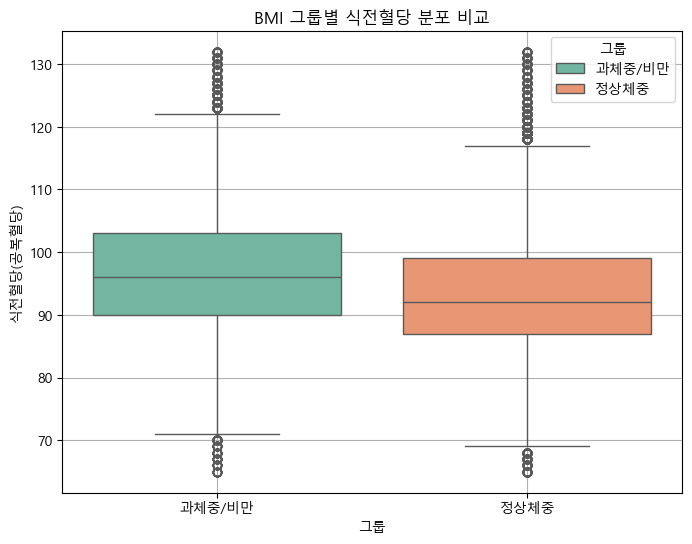

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('csv/2.BMI와 혈당.csv', encoding='euc-kr')

plt.rcParams['font.family'] = 'Malgun Gothic'

plt.figure(figsize=(8, 6))
sns.boxplot(x='그룹', y='식전혈당(공복혈당)', hue='그룹', data=df, palette="Set2")

plt.title('BMI 그룹별 식전혈당 분포 비교')
plt.ylabel('식전혈당(공복혈당)')
plt.grid(True)

plt.show()


C:\Users\김소연\AppData\Local\Temp\ipykernel_32444\3932477734.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='복부비만여부', y='식전혈당(공복혈당)', data=df, palette="viridis")


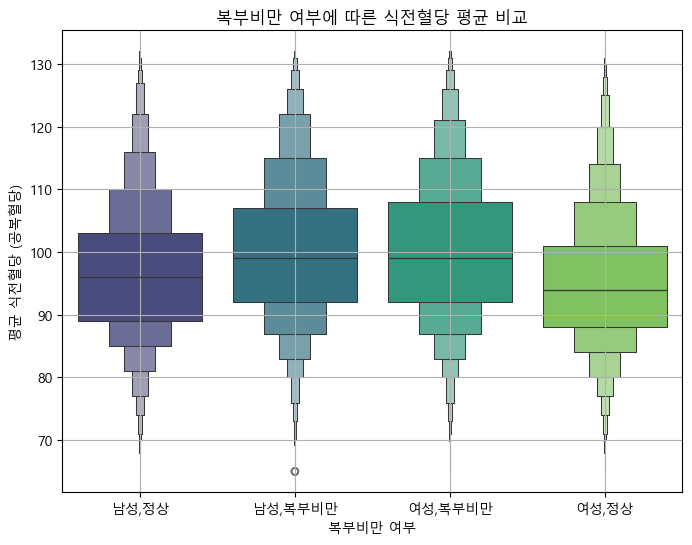

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('csv/4.허리둘레와 혈당.csv', encoding='euc-kr')

plt.rcParams['font.family'] = 'Malgun Gothic'

plt.figure(figsize=(8, 6))
sns.boxenplot(x='복부비만여부', y='식전혈당(공복혈당)', data=df, palette="viridis")
plt.title('복부비만 여부에 따른 식전혈당 평균 비교')
plt.xlabel('복부비만 여부')
plt.ylabel('평균 식전혈당 (공복혈당)')
plt.grid(True)

plt.show()

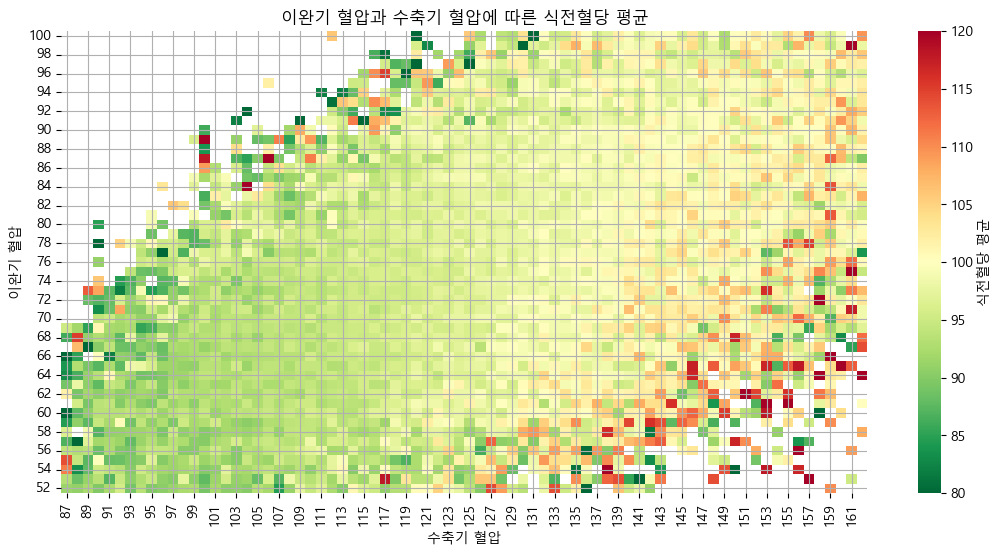

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('csv/3.혈압과 혈당.csv', encoding='euc-kr')

plt.rcParams['font.family'] = 'Malgun Gothic'

pivot_df = df.pivot_table(index="이완기혈압", columns="수축기혈압", values="식전혈당(공복혈당)", aggfunc="mean")
pivot_df = pivot_df[::-1] # y축이 꺼꾸로 나와서

plt.figure(figsize=(13, 6))
sns.heatmap(pivot_df, cmap="RdYlGn_r", cbar_kws={'label': '식전혈당 평균'},vmin=80, vmax=120)
plt.title('이완기 혈압과 수축기 혈압에 따른 식전혈당 평균')
plt.xlabel('수축기 혈압')
plt.ylabel('이완기 혈압')
plt.grid(True)

plt.show()